In [2]:
import torch
import os

dir_loaders = 'dataloaders'
rock_loader = torch.load(os.path.join(dir_loaders, 'rock_dataloader_zeros.pt'), weights_only=False)
paper_loader = torch.load(os.path.join(dir_loaders, 'paper_dataloader_zeros.pt'), weights_only=False)
scissor_loader = torch.load(os.path.join(dir_loaders, 'scissor_dataloader_zeros.pt'), weights_only=False)

all_rocks = []
for x, y in rock_loader:
    all_rocks.append(x[y==1])
all_rocks = torch.cat(all_rocks, dim=0)

all_papers = []
for x, y in paper_loader:
    all_papers.append(x[y==1])
all_papers = torch.cat(all_papers, dim=0)

all_scissors = []
for x, y in scissor_loader:
    all_scissors.append(x[y==1])
all_scissors = torch.cat(all_scissors, dim=0)

print(all_rocks.shape)
print(all_papers.shape)
print(all_scissors.shape)

all_data = {
    "rock": all_rocks,
    "paper": all_papers,
    "scissor": all_scissors
}


torch.Size([296, 1, 8, 400])
torch.Size([296, 1, 8, 400])
torch.Size([296, 1, 8, 400])


In [4]:
import torch
import numpy as np
import pywt
from scipy.signal import welch
import os

# ---------- Feature functions ----------
def rms(signal):
    return np.sqrt(np.mean(signal**2))

def waveform_length(signal):
    return np.sum(np.abs(np.diff(signal)))

def zero_crossings(signal, threshold=0.01):
    # Count sign changes with threshold
    return np.sum(((signal[:-1] * signal[1:]) < 0) &
                  (np.abs(signal[:-1] - signal[1:]) > threshold))

def slope_sign_changes(signal, threshold=0.01):
    # Detect slope sign changes
    diff = np.diff(signal)
    return np.sum(((diff[:-1] * diff[1:]) < 0) &
                  (np.abs(diff[:-1] - diff[1:]) > threshold))

def median_freq(signal, fs=1000):  # <-- adjust fs if known
    freqs, psd = welch(signal, fs=fs, nperseg=min(256, len(signal)))
    cumulative = np.cumsum(psd)
    cutoff = cumulative[-1] / 2
    return freqs[np.where(cumulative >= cutoff)[0][0]]

def sample_entropy(signal, m=2, r=0.2):
    # Approximate sample entropy
    N = len(signal)
    r *= np.std(signal)
    
    def _phi(m):
        x = np.array([signal[i:i+m] for i in range(N - m + 1)])
        C = np.sum(np.sum(np.abs(x[:,None] - x[None,:]), axis=2) <= r, axis=0) - 1
        return np.sum(C) / ((N - m + 1) * (N - m))
    
    ratio = _phi(m+1) / (_phi(m) + 1e-12)
    ratio = np.clip(ratio, 1e-12, None)
    return -np.log(ratio)

def shannon_entropy(signal, bins=30):
    hist, _ = np.histogram(signal, bins=bins, density=True)
    hist = np.clip(hist, 1e-12, None)
    return -np.sum(hist * np.log2(hist))

def wavelet_energy(signal, wavelet='db4', level=3):
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    energies = [np.sum(np.square(c)) for c in coeffs]
    return np.sum(energies)

def higuchi_fd(signal, kmax=10):
    # Higuchi fractal dimension
    N = len(signal)
    L = []
    x = signal
    for k in range(1, kmax+1):
        Lk = []
        for m in range(k):
            idx = np.arange(m, N, k)
            Lm = np.sum(np.abs(np.diff(x[idx]))) * (N-1)/(((N-m)//k) * k)
            Lk.append(Lm)
        L.append(np.mean(Lk))
    L = np.log(np.clip(L, 1e-12, None))
    ln_k = np.log(np.clip(1.0/np.arange(1, kmax+1), 1e-12, None))
    return -np.polyfit(ln_k, L, 1)[0]

# ---------- Main extractor ----------
def extract_emg_features(emg_np, fs=1000):
    """
    emg_tensor: torch.Size([samples, 1, channels, timesteps])
    Returns: numpy array of shape [samples, channels * n_features]
    """
    # emg_np = emg_tensor.squeeze(1).numpy()  # shape: [samples, channels, timesteps]
    n_samples, n_channels, n_timesteps = emg_np.shape
    
    features = []
    for s in range(n_samples):
        sample_feats = []
        for ch in range(n_channels):
            sig = emg_np[s, ch, :]
            
            feats = [
                rms(sig),
                waveform_length(sig),
                zero_crossings(sig),
                slope_sign_changes(sig),
                median_freq(sig, fs),
                sample_entropy(sig),
                shannon_entropy(sig),
                wavelet_energy(sig),
                higuchi_fd(sig),
            ]
            sample_feats.extend(feats)
        features.append(sample_feats)
    
    return np.array(features)


In [ ]:
if __name__ == "__main__":
    dir_loaders = 'dataloaders'
    types = ['rock', 'paper', 'scissor']

    feature_data = {}

    for _type in types:
        print(f'Processing {_type} data...')
        loader = torch.load(os.path.join(dir_loaders, f'{_type}_dataloader_zeros.pt'), weights_only=False)

        # Load data
        all_x = []
        for x, y in loader:
            all_x.append(x[y==1])
        all_x = torch.cat(all_x, dim=0)

        all_x = all_x.squeeze(1).numpy()

        X_feats = extract_emg_features(all_x, fs=100)
        print("Feature matrix shape:", X_feats.shape)

        feature_data[_type] = X_feats



Paper vs Scissor: 0.9453809908718867
Rock vs Scissor: 12.9360718464663
Rock vs Paper: 10.888213461060227


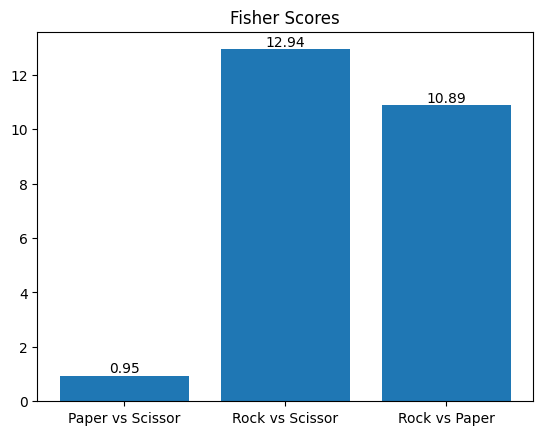

In [3]:
def compute_fisher_scores(data1, data2):
    m1 = np.mean(data1, axis=0)
    m2 = np.mean(data2, axis=0)
    v1 = np.var(data1, axis=0, ddof=0)
    v2 = np.var(data2, axis=0, ddof=0)
    scores = (m1 - m2)**2 / (v1 + v2 + 1e-12)
    return np.max(scores)

paper_scissor = compute_fisher_scores(feature_data["paper"], feature_data["scissor"])
rock_scissor = compute_fisher_scores(feature_data["rock"], feature_data["scissor"])
rock_paper = compute_fisher_scores(feature_data["rock"], feature_data["paper"])

print(f"Paper vs Scissor: {paper_scissor}")
print(f"Rock vs Scissor: {rock_scissor}")
print(f"Rock vs Paper: {rock_paper}")

import matplotlib.pyplot as plt

bars = plt.bar(x=["Paper vs Scissor", "Rock vs Scissor", "Rock vs Paper"], height=[paper_scissor, rock_scissor, rock_paper])
for bar, val in zip(bars, [paper_scissor, rock_scissor, rock_paper]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{val:.2f}", ha='center', va='bottom')
plt.title("Fisher Scores")
plt.show()

## Within class Fisher analysis:

#### Finding which sensors are crucial using Fisher score


In [8]:
dir_loaders = 'dataloaders'

fisher_scores = {}

types = ['rock', 'paper', 'scissor']

for _type in types:
    baseline = feature_data[_type]
    data = all_data[_type].squeeze(1).numpy()

    scores_type = []

    print(_type)
    for sensor in range(8):
        data_copy = data.copy()
        data_copy[:, sensor, :] = 0
        extracted_features = extract_emg_features(data_copy, fs=100)
        fisher_score = compute_fisher_scores(extracted_features, baseline)
        scores_type.append(fisher_score)

        print(f"  S_{sensor} v Base: {fisher_score:.2f}")

    fisher_scores[_type] = scores_type

fisher_scores

rock
  S_0 v Base: 7750.96
  S_1 v Base: 13649.93
  S_2 v Base: 4448.41
  S_3 v Base: 18538.18
  S_4 v Base: 21652.41
  S_5 v Base: 12712.41
  S_6 v Base: 2642.36
  S_7 v Base: 9137.92
paper
  S_0 v Base: 1500.30
  S_1 v Base: 12444.26
  S_2 v Base: 5253.27
  S_3 v Base: 8560.44
  S_4 v Base: 5148.37
  S_5 v Base: 1174.87
  S_6 v Base: 1328.75
  S_7 v Base: 5577.85
scissor
  S_0 v Base: 1892.48
  S_1 v Base: 4338.22
  S_2 v Base: 9441.67
  S_3 v Base: 11266.88
  S_4 v Base: 12786.24
  S_5 v Base: 1274.84
  S_6 v Base: 1526.17
  S_7 v Base: 7160.19


{'rock': [np.float64(7750.963760808535),
  np.float64(13649.932722426429),
  np.float64(4448.407563141643),
  np.float64(18538.18393482626),
  np.float64(21652.41482455931),
  np.float64(12712.409807773549),
  np.float64(2642.3638040586206),
  np.float64(9137.920451811942)],
 'paper': [np.float64(1500.2991077158729),
  np.float64(12444.257527380996),
  np.float64(5253.266048760941),
  np.float64(8560.436520234378),
  np.float64(5148.368617509792),
  np.float64(1174.8693868142648),
  np.float64(1328.754778522503),
  np.float64(5577.852358738581)],
 'scissor': [np.float64(1892.4830119736605),
  np.float64(4338.220377438928),
  np.float64(9441.668840809969),
  np.float64(11266.882759292339),
  np.float64(12786.235910869424),
  np.float64(1274.839765693973),
  np.float64(1526.171192919801),
  np.float64(7160.19161572922)]}

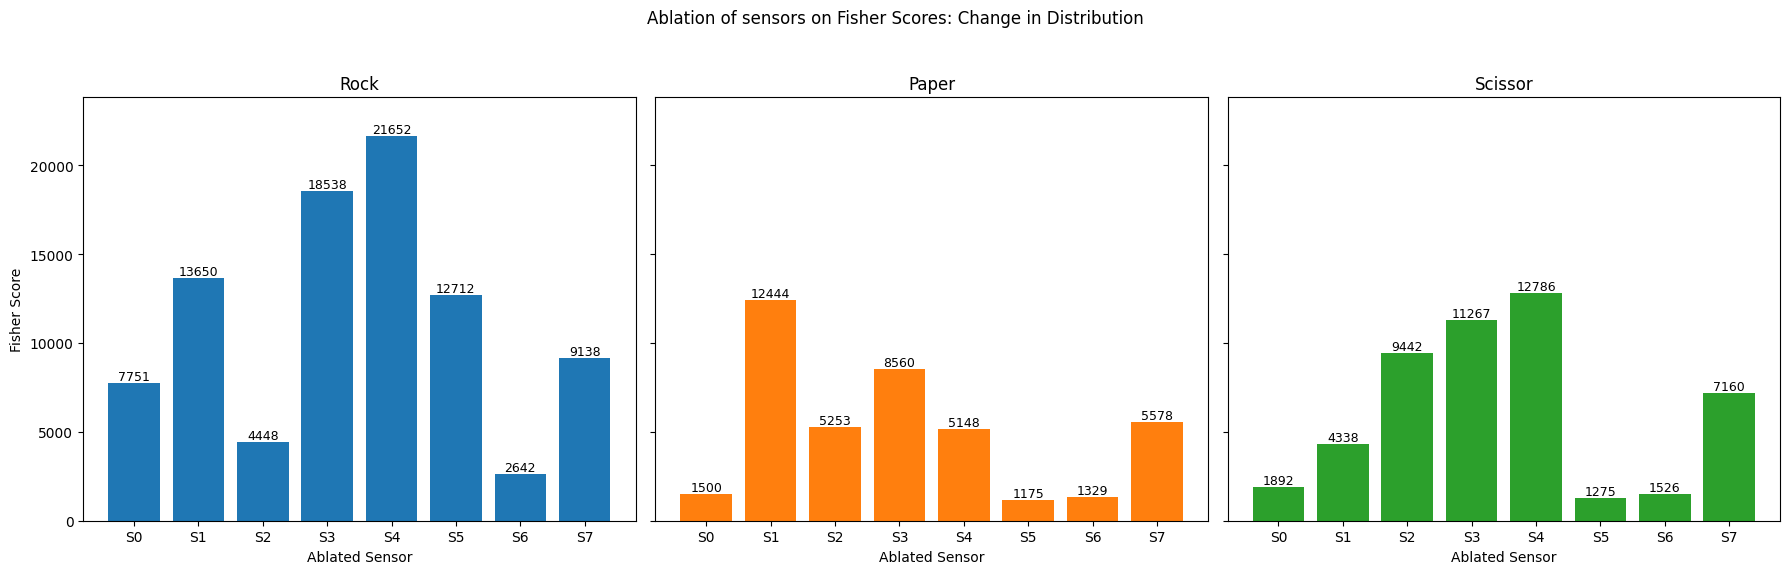

In [11]:
import matplotlib.pyplot as plt
import numpy as np

sensor_labels = [f"S{i}" for i in range(8)]
fig, axs = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for idx, gesture in enumerate(['rock', 'paper', 'scissor']):
    ax = axs[idx]
    values = [float(v) for v in fisher_scores[gesture]]
    bars = ax.bar(sensor_labels, values, color='C'+str(idx))
    ax.set_title(f"{gesture.capitalize()}")
    ax.set_xlabel("Ablated Sensor")
    if idx == 0:
        ax.set_ylabel("Fisher Score")
    ax.set_ylim(0, max(max([float(v) for v in vals]) for vals in fisher_scores.values()) * 1.1)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{val:.0f}", ha='center', va='bottom', fontsize=9)

plt.suptitle("Ablation of sensors on Fisher Scores: Change in Distribution")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


## Very simple MLP classification


In [5]:
# prepare data

rock = all_data["rock"]
paper = all_data["paper"]
scissor = all_data["scissor"]

dir_loaders = 'dataloaders'
types = ['rock', 'paper', 'scissor']

feature_data = {}

for _type in types:
    print(f'Processing {_type} data...')
    loader = torch.load(os.path.join(dir_loaders, f'{_type}_dataloader_zeros.pt'), weights_only=False)

    # Load data
    all_x = []
    x_null = []
    for x, y in loader:
        all_x.append(x[y==1])
        x_null.append(x[y==0])
    all_x = torch.cat(all_x, dim=0)
    x_null = torch.cat(x_null, dim=0)
    
    all_x = all_x.squeeze(1).numpy()
    x_null = x_null.squeeze(1).numpy()
    
    X_feats = extract_emg_features(all_x, fs=100)
    X_null = extract_emg_features(x_null, fs=100)
    print("Feature matrix shape:", X_feats.shape)

    feature_data[_type] = X_feats
    feature_data["null"] = X_null

feature_data

Processing rock data...
Feature matrix shape: (296, 72)
Processing paper data...
Feature matrix shape: (296, 72)
Processing scissor data...
Feature matrix shape: (296, 72)


{'rock': array([[  1.83762944, 833.19824219, 180.        , ...,   5.47564479,
         786.88348389,  -1.0495113 ],
        [  1.50663269, 687.11743164, 183.        , ...,   6.98287497,
         160.03286743,  -1.0452522 ],
        [  1.81964004, 880.48461914, 198.        , ...,   8.19695118,
         510.17645264,  -1.04561182],
        ...,
        [  1.20457625, 447.96484375, 171.        , ...,   5.05194552,
         535.49871826,  -1.02471735],
        [  1.46592009, 641.27886963, 190.        , ...,   6.76218281,
         570.62774658,  -1.05536113],
        [  1.61895871, 731.2074585 , 177.        , ...,   6.55595931,
         305.97061157,  -1.04586306]], shape=(296, 72)),
 'null': array([[ 3.55524540e-01,  9.10247955e+01,  1.51000000e+02, ...,
         -2.89849691e+00,  6.00080452e+01, -9.91935382e-01],
        [ 5.84143221e-01,  1.44816315e+02,  1.28000000e+02, ...,
          5.23408866e-01,  1.84875305e+02, -8.71258667e-01],
        [ 2.20664263e-01,  7.09527588e+01,  1.620000

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# Use MPS if available, else fallback to CPU
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# Prepare data and labels
X = []
y = []
label_map = {'rock': 0, 'paper': 1, 'scissor': 2, 'null': 3}
for k in ['rock', 'paper', 'scissor', 'null']:
    X.append(feature_data[k])
    y.append(np.full(feature_data[k].shape[0], label_map[k]))
X = np.vstack(X)
y = np.concatenate(y)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Convert to torch tensors and move to device
X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.long).to(device)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test, dtype=torch.long).to(device)

# Simple MLP model
class SimpleMLP(nn.Module):
    def __init__(self, input_dim=72, hidden_dim=64, num_classes=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes)
        )
    def forward(self, x):
        return self.net(x)

model = SimpleMLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Training loop
n_epochs = 30
batch_size = 32

for epoch in range(n_epochs):
    model.train()
    perm = torch.randperm(X_train.size(0), device=device)
    X_train_shuffled = X_train[perm]
    y_train_shuffled = y_train[perm]
    for i in range(0, X_train.size(0), batch_size):
        xb = X_train_shuffled[i:i+batch_size]
        yb = y_train_shuffled[i:i+batch_size]
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
    if (epoch+1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.4f}")

# Evaluation
model.eval()
with torch.no_grad():
    logits = model(X_test)
    preds = torch.argmax(logits, dim=1).cpu().numpy()
    y_true = y_test.cpu().numpy()
    acc = accuracy_score(y_true, preds)
    print(f"Test accuracy: {acc:.4f}")
    print(classification_report(y_true, preds, target_names=['rock', 'paper', 'scissor', 'null']))

import seaborn as sns
from sklearn.metrics import confusion_matrix

# Plot confusion matrix
cm = confusion_matrix(y_true, preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['rock', 'paper', 'scissor', 'null'],
            yticklabels=['rock', 'paper', 'scissor', 'null'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

Using device: mps
Epoch 1/30, Loss: 0.4709
Epoch 5/30, Loss: 0.2222
Epoch 10/30, Loss: 0.0202
Epoch 15/30, Loss: 0.3649
Epoch 20/30, Loss: 0.1652
Epoch 25/30, Loss: 0.0183
Epoch 30/30, Loss: 0.0868
Test accuracy: 0.8903
              precision    recall  f1-score   support

        rock       0.95      1.00      0.98        59
       paper       0.94      0.76      0.84        59
     scissor       0.96      0.82      0.88        60
        null       0.76      0.98      0.86        59

    accuracy                           0.89       237
   macro avg       0.90      0.89      0.89       237
weighted avg       0.90      0.89      0.89       237



Using device: mps
Epoch 1/30, Loss: 0.0151
Epoch 5/30, Loss: 0.0103
Epoch 10/30, Loss: 1.2288
Epoch 15/30, Loss: 0.0005
Epoch 20/30, Loss: 0.0003
Epoch 25/30, Loss: 0.4807
Epoch 30/30, Loss: 0.0149
Test accuracy: 0.9326
              precision    recall  f1-score   support

        rock       0.97      1.00      0.98        59
       paper       0.91      0.88      0.90        59
     scissor       0.92      0.92      0.92        60

    accuracy                           0.93       178
   macro avg       0.93      0.93      0.93       178
weighted avg       0.93      0.93      0.93       178



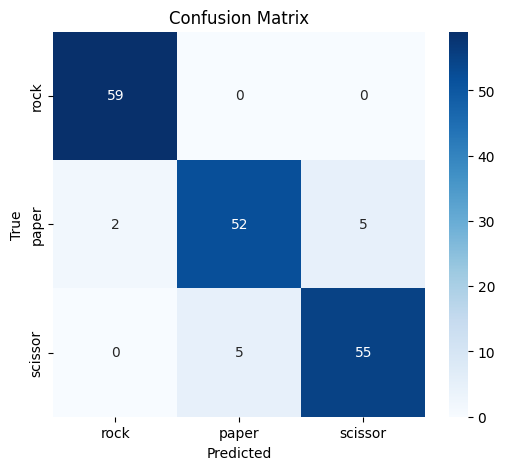

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# Use MPS if available, else fallback to CPU
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# Prepare data and labels
X = []
y = []
label_map = {'rock': 0, 'paper': 1, 'scissor': 2}
for k in ['rock', 'paper', 'scissor']:
    X.append(feature_data[k])
    y.append(np.full(feature_data[k].shape[0], label_map[k]))
X = np.vstack(X)
y = np.concatenate(y)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Convert to torch tensors and move to device
X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.long).to(device)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test, dtype=torch.long).to(device)

# Simple MLP model
class SimpleMLP(nn.Module):
    def __init__(self, input_dim=72, hidden_dim=64, num_classes=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes)
        )
    def forward(self, x):
        return self.net(x)

model = SimpleMLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Training loop
n_epochs = 30
batch_size = 32

for epoch in range(n_epochs):
    model.train()
    perm = torch.randperm(X_train.size(0), device=device)
    X_train_shuffled = X_train[perm]
    y_train_shuffled = y_train[perm]
    for i in range(0, X_train.size(0), batch_size):
        xb = X_train_shuffled[i:i+batch_size]
        yb = y_train_shuffled[i:i+batch_size]
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
    if (epoch+1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.4f}")

# Evaluation
model.eval()
with torch.no_grad():
    logits = model(X_test)
    preds = torch.argmax(logits, dim=1).cpu().numpy()
    y_true = y_test.cpu().numpy()
    acc = accuracy_score(y_true, preds)
    print(f"Test accuracy: {acc:.4f}")
    print(classification_report(y_true, preds, target_names=['rock', 'paper', 'scissor']))

import seaborn as sns
from sklearn.metrics import confusion_matrix

# Plot confusion matrix
cm = confusion_matrix(y_true, preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['rock', 'paper', 'scissor'],
            yticklabels=['rock', 'paper', 'scissor'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

Using device: mps

=== Training binary model: rock vs null ===
Epoch 1/30, Loss: 1.4667
Epoch 5/30, Loss: 0.0012
Epoch 10/30, Loss: 0.0000
Epoch 15/30, Loss: 0.0075
Epoch 20/30, Loss: 0.2032
Epoch 25/30, Loss: 0.0000
Epoch 30/30, Loss: 0.0000
Test accuracy: 1.0000
              precision    recall  f1-score   support

        rock       1.00      1.00      1.00        60
        null       1.00      1.00      1.00        59

    accuracy                           1.00       119
   macro avg       1.00      1.00      1.00       119
weighted avg       1.00      1.00      1.00       119



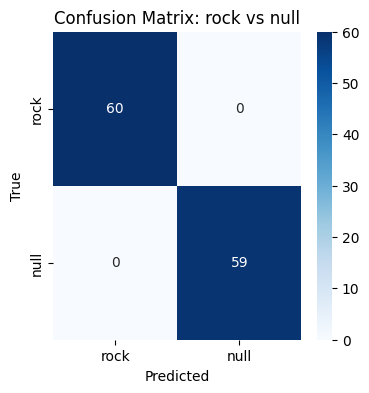


=== Training binary model: paper vs null ===
Epoch 1/30, Loss: 0.8147
Epoch 5/30, Loss: 0.0949
Epoch 10/30, Loss: 0.0529
Epoch 15/30, Loss: 0.0835
Epoch 20/30, Loss: 0.2044
Epoch 25/30, Loss: 0.2937
Epoch 30/30, Loss: 0.0412
Test accuracy: 0.9748
              precision    recall  f1-score   support

       paper       1.00      0.95      0.97        60
        null       0.95      1.00      0.98        59

    accuracy                           0.97       119
   macro avg       0.98      0.97      0.97       119
weighted avg       0.98      0.97      0.97       119



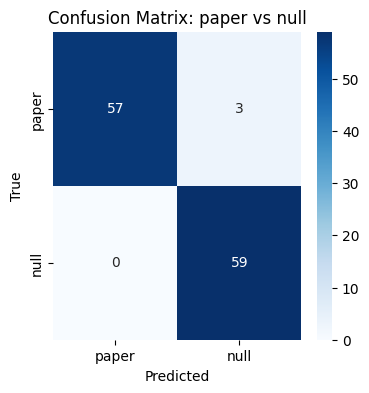


=== Training binary model: scissor vs null ===
Epoch 1/30, Loss: 1.5119
Epoch 5/30, Loss: 0.1073
Epoch 10/30, Loss: 0.8953
Epoch 15/30, Loss: 0.0007
Epoch 20/30, Loss: 0.0000
Epoch 25/30, Loss: 0.0000
Epoch 30/30, Loss: 0.3330
Test accuracy: 0.9496
              precision    recall  f1-score   support

     scissor       0.94      0.97      0.95        60
        null       0.96      0.93      0.95        59

    accuracy                           0.95       119
   macro avg       0.95      0.95      0.95       119
weighted avg       0.95      0.95      0.95       119



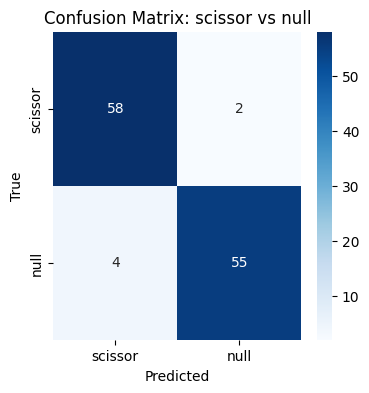

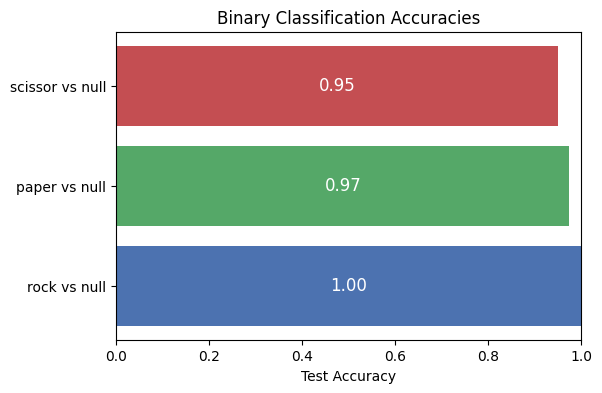

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Use MPS if available, else fallback to CPU
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# Define binary tasks
binary_tasks = [
    ("rock", "null"),
    ("paper", "null"),
    ("scissor", "null"),
]

class SimpleMLP(nn.Module):
    def __init__(self, input_dim=72, hidden_dim=64, num_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes)
        )
    def forward(self, x):
        return self.net(x)

# Store accuracies for each task
task_accuracies = []
task_names = []

for pos_class, neg_class in binary_tasks:
    print(f"\n=== Training binary model: {pos_class} vs {neg_class} ===")
    # Prepare data and labels for this binary task
    X = []
    y = []
    X.append(feature_data[pos_class])
    y.append(np.zeros(feature_data[pos_class].shape[0], dtype=np.int64))  # label 0 for pos_class
    X.append(feature_data[neg_class])
    y.append(np.ones(feature_data[neg_class].shape[0], dtype=np.int64))   # label 1 for neg_class
    X = np.vstack(X)
    y = np.concatenate(y)

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Convert to torch tensors and move to device
    X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_train = torch.tensor(y_train, dtype=torch.long).to(device)
    X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_test = torch.tensor(y_test, dtype=torch.long).to(device)

    # Model, loss, optimizer
    model = SimpleMLP(input_dim=X_train.shape[1], hidden_dim=64, num_classes=2).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    # Training loop
    n_epochs = 30
    batch_size = 32

    for epoch in range(n_epochs):
        model.train()
        perm = torch.randperm(X_train.size(0), device=device)
        X_train_shuffled = X_train[perm]
        y_train_shuffled = y_train[perm]
        for i in range(0, X_train.size(0), batch_size):
            xb = X_train_shuffled[i:i+batch_size]
            yb = y_train_shuffled[i:i+batch_size]
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
        if (epoch+1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.4f}")

    # Evaluation
    model.eval()
    with torch.no_grad():
        logits = model(X_test)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        y_true = y_test.cpu().numpy()
        acc = accuracy_score(y_true, preds)
        print(f"Test accuracy: {acc:.4f}")
        print(classification_report(
            y_true, preds, target_names=[pos_class, neg_class]
        ))
        # Store accuracy and task name for plotting
        task_accuracies.append(acc)
        task_names.append(f"{pos_class} vs {neg_class}")

    # Plot confusion matrix
    cm = confusion_matrix(y_true, preds)
    plt.figure(figsize=(4,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[pos_class, neg_class],
                yticklabels=[pos_class, neg_class])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix: {pos_class} vs {neg_class}')
    plt.show()

# Plot all accuracies in one figure
plt.figure(figsize=(6,4))
bars = plt.barh(task_names, task_accuracies, color=['#4C72B0', '#55A868', '#C44E52'])
plt.xlim(0, 1)
plt.xlabel('Test Accuracy')
plt.title('Binary Classification Accuracies')
for bar, acc in zip(bars, task_accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_y() + bar.get_height()/2, f"{acc:.2f}", 
             ha='center', va='center', fontsize=12, color='white' if acc > 0.5 else 'black')
plt.show()

Using device: mps

=== Training binary model: rock vs paper ===
Epoch 1/30, Loss: 0.0002
Epoch 5/30, Loss: 0.0011
Epoch 10/30, Loss: 0.0000
Epoch 15/30, Loss: 0.0000
Epoch 20/30, Loss: 0.0000
Epoch 25/30, Loss: 0.0305
Epoch 30/30, Loss: 0.0000
Test accuracy: 0.9916
              precision    recall  f1-score   support

        rock       0.98      1.00      0.99        60
       paper       1.00      0.98      0.99        59

    accuracy                           0.99       119
   macro avg       0.99      0.99      0.99       119
weighted avg       0.99      0.99      0.99       119



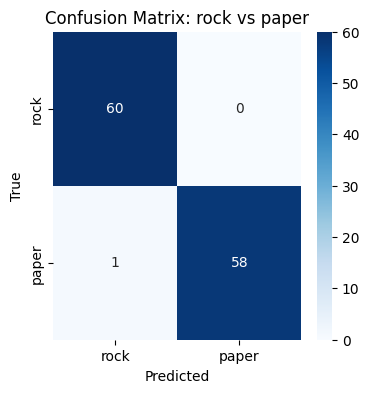


=== Training binary model: rock vs scissor ===
Epoch 1/30, Loss: 2.3113
Epoch 5/30, Loss: 0.0000
Epoch 10/30, Loss: 0.0017
Epoch 15/30, Loss: 0.0000
Epoch 20/30, Loss: 0.0000
Epoch 25/30, Loss: 0.0000
Epoch 30/30, Loss: 0.0000
Test accuracy: 1.0000
              precision    recall  f1-score   support

        rock       1.00      1.00      1.00        60
     scissor       1.00      1.00      1.00        59

    accuracy                           1.00       119
   macro avg       1.00      1.00      1.00       119
weighted avg       1.00      1.00      1.00       119



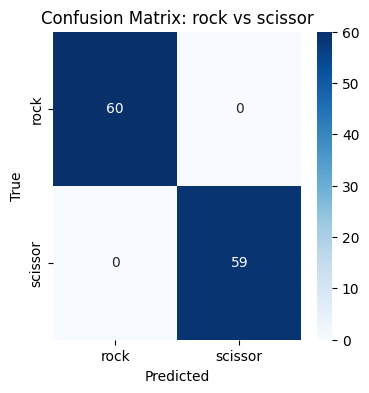


=== Training binary model: paper vs scissor ===
Epoch 1/30, Loss: 1.9288
Epoch 5/30, Loss: 0.7346
Epoch 10/30, Loss: 0.1537
Epoch 15/30, Loss: 0.2834
Epoch 20/30, Loss: 0.0117
Epoch 25/30, Loss: 0.0233
Epoch 30/30, Loss: 0.1374
Test accuracy: 0.8571
              precision    recall  f1-score   support

       paper       0.78      1.00      0.88        60
     scissor       1.00      0.71      0.83        59

    accuracy                           0.86       119
   macro avg       0.89      0.86      0.85       119
weighted avg       0.89      0.86      0.85       119



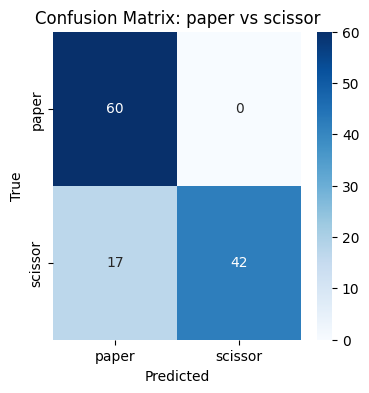

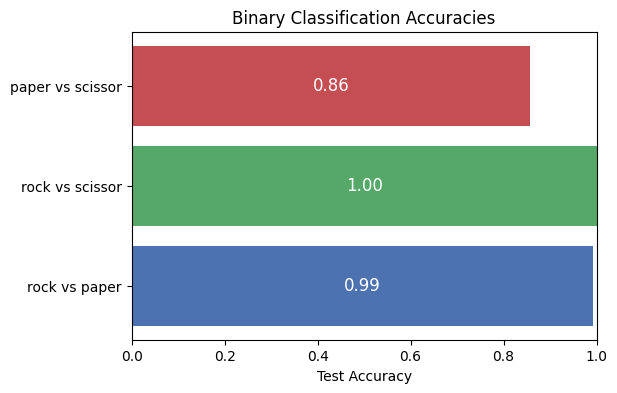

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Use MPS if available, else fallback to CPU
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# Define binary tasks
binary_tasks = [
    ("rock", "paper"),
    ("rock", "scissor"),
    ("paper", "scissor"),
]

class SimpleMLP(nn.Module):
    def __init__(self, input_dim=72, hidden_dim=64, num_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes)
        )
    def forward(self, x):
        return self.net(x)

# Store accuracies for each task
task_accuracies = []
task_names = []

for pos_class, neg_class in binary_tasks:
    print(f"\n=== Training binary model: {pos_class} vs {neg_class} ===")
    # Prepare data and labels for this binary task
    X = []
    y = []
    X.append(feature_data[pos_class])
    y.append(np.zeros(feature_data[pos_class].shape[0], dtype=np.int64))  # label 0 for pos_class
    X.append(feature_data[neg_class])
    y.append(np.ones(feature_data[neg_class].shape[0], dtype=np.int64))   # label 1 for neg_class
    X = np.vstack(X)
    y = np.concatenate(y)

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Convert to torch tensors and move to device
    X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_train = torch.tensor(y_train, dtype=torch.long).to(device)
    X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_test = torch.tensor(y_test, dtype=torch.long).to(device)

    # Model, loss, optimizer
    model = SimpleMLP(input_dim=X_train.shape[1], hidden_dim=64, num_classes=2).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    # Training loop
    n_epochs = 30
    batch_size = 32

    for epoch in range(n_epochs):
        model.train()
        perm = torch.randperm(X_train.size(0), device=device)
        X_train_shuffled = X_train[perm]
        y_train_shuffled = y_train[perm]
        for i in range(0, X_train.size(0), batch_size):
            xb = X_train_shuffled[i:i+batch_size]
            yb = y_train_shuffled[i:i+batch_size]
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
        if (epoch+1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.4f}")

    # Evaluation
    model.eval()
    with torch.no_grad():
        logits = model(X_test)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        y_true = y_test.cpu().numpy()
        acc = accuracy_score(y_true, preds)
        print(f"Test accuracy: {acc:.4f}")
        print(classification_report(
            y_true, preds, target_names=[pos_class, neg_class]
        ))
        # Store accuracy and task name for plotting
        task_accuracies.append(acc)
        task_names.append(f"{pos_class} vs {neg_class}")

    # Plot confusion matrix
    cm = confusion_matrix(y_true, preds)
    plt.figure(figsize=(4,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[pos_class, neg_class],
                yticklabels=[pos_class, neg_class])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix: {pos_class} vs {neg_class}')
    plt.show()

# Plot all accuracies in one figure
plt.figure(figsize=(6,4))
bars = plt.barh(task_names, task_accuracies, color=['#4C72B0', '#55A868', '#C44E52'])
plt.xlim(0, 1)
plt.xlabel('Test Accuracy')
plt.title('Binary Classification Accuracies')
for bar, acc in zip(bars, task_accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_y() + bar.get_height()/2, f"{acc:.2f}", 
             ha='center', va='center', fontsize=12, color='white' if acc > 0.5 else 'black')
plt.show()

# Below, for later paper, not CHI


In [ ]:
# escape:
exit(0)



# Sensor Importance Analysis
# This analysis shows which sensors have the most impact on classification performance
# by systematically zeroing out individual sensors and measuring the change in Fisher scores

def analyze_sensor_importance(class1_data, class2_data, class1_name, class2_name):
    """
    Analyze sensor importance by zeroing out individual sensors and computing Fisher score deltas vs baseline
    
    Args:
        class1_data: tensor of shape [samples, 1, 8, 400] for first class
        class2_data: tensor of shape [samples, 1, 8, 400] for second class
        class1_name: name of first class
        class2_name: name of second class
    
    Returns:
        delta_matrix: 8x8 matrix of Fisher score deltas (zeroed - baseline)
    """
    n_sensors = 8
    delta_matrix = np.zeros((n_sensors, n_sensors))
    
    # Compute baseline (no sensors zeroed)
    baseline_c1_feats = extract_emg_features(class1_data, fs=100)
    baseline_c2_feats = extract_emg_features(class2_data, fs=100)
    baseline_score = compute_fisher_scores(baseline_c1_feats, baseline_c2_feats)
    print(f"Baseline Fisher score for {class1_name} vs {class2_name}: {baseline_score:.4f}")
    
    print(f"Analyzing sensor importance for {class1_name} vs {class2_name}...")
    
    for i in range(n_sensors):
        # Zero out sensor i in class1
        class1_modified = class1_data.clone()
        class1_modified[:, :, i, :] = 0
        
        for j in range(n_sensors):
            # Zero out sensor j in class2
            class2_modified = class2_data.clone()
            class2_modified[:, :, j, :] = 0
            
            # Extract features from modified data
            class1_features = extract_emg_features(class1_modified, fs=100)
            class2_features = extract_emg_features(class2_modified, fs=100)
            
            # Compute Fisher score and delta vs baseline
            fisher_score = compute_fisher_scores(class1_features, class2_features)
            delta = fisher_score - baseline_score
            delta_matrix[i, j] = delta
            
            print(f"  Sensor {i+1} ({class1_name}) + Sensor {j+1} ({class2_name}) zeroed: F-score = {fisher_score:.4f} (Δ = {delta:.4f})")
    
    return delta_matrix

# Perform sensor importance analysis for all class combinations
print("=" * 60)
print("SENSOR IMPORTANCE ANALYSIS")
print("=" * 60)

# Rock vs Scissor analysis
rock_scissor_matrix = analyze_sensor_importance(all_rocks, all_scissors, "Rock", "Scissor")

print("\n" + "=" * 60)
print("Rock vs Scissor Sensor Impact (Δ vs baseline)")
print("Rows: Rock sensors zeroed, Columns: Scissor sensors zeroed")
print("=" * 60)
print(rock_scissor_matrix)


SENSOR IMPORTANCE ANALYSIS
Baseline Fisher score for Rock vs Scissor: 12.9361
Analyzing sensor importance for Rock vs Scissor...


KeyboardInterrupt: 

: 

In [ ]:
# Paper vs Scissor analysis
paper_scissor_matrix = analyze_sensor_importance(all_papers, all_scissors, "Paper", "Scissor")

print("\n" + "=" * 60)
print("Paper vs Scissor Sensor Importance Matrix")
print("Rows: Paper sensors zeroed, Columns: Scissor sensors zeroed")
print("=" * 60)
print(paper_scissor_matrix)


Baseline Fisher score for Paper vs Scissor: 0.9454
Analyzing sensor importance for Paper vs Scissor...
  Sensor 1 (Paper) + Sensor 1 (Scissor) zeroed: F-score = 0.9454 (Δ = 0.0000)
  Sensor 1 (Paper) + Sensor 2 (Scissor) zeroed: F-score = 12444.2575 (Δ = 12443.3121)
  Sensor 1 (Paper) + Sensor 3 (Scissor) zeroed: F-score = 5253.2660 (Δ = 5252.3207)
  Sensor 1 (Paper) + Sensor 4 (Scissor) zeroed: F-score = 8560.4365 (Δ = 8559.4911)
  Sensor 1 (Paper) + Sensor 5 (Scissor) zeroed: F-score = 5148.3686 (Δ = 5147.4232)
  Sensor 1 (Paper) + Sensor 6 (Scissor) zeroed: F-score = 1892.4830 (Δ = 1891.5376)
  Sensor 1 (Paper) + Sensor 7 (Scissor) zeroed: F-score = 1892.4830 (Δ = 1891.5376)
  Sensor 1 (Paper) + Sensor 8 (Scissor) zeroed: F-score = 5577.8524 (Δ = 5576.9070)
  Sensor 2 (Paper) + Sensor 1 (Scissor) zeroed: F-score = 4338.2204 (Δ = 4337.2750)
  Sensor 2 (Paper) + Sensor 2 (Scissor) zeroed: F-score = 0.1581 (Δ = -0.7873)
  Sensor 2 (Paper) + Sensor 3 (Scissor) zeroed: F-score = 5253.266

In [ ]:
# Rock vs Paper analysis
rock_paper_matrix = analyze_sensor_importance(all_rocks, all_papers, "Rock", "Paper")

print("\n" + "=" * 60)
print("Rock vs Paper Sensor Importance Matrix")
print("Rows: Rock sensors zeroed, Columns: Paper sensors zeroed")
print("=" * 60)
print(rock_paper_matrix)


Baseline Fisher score for Rock vs Paper: 10.8882
Analyzing sensor importance for Rock vs Paper...
  Sensor 1 (Rock) + Sensor 1 (Paper) zeroed: F-score = 1.1136 (Δ = -9.7746)
  Sensor 1 (Rock) + Sensor 2 (Paper) zeroed: F-score = 13649.9327 (Δ = 13639.0445)
  Sensor 1 (Rock) + Sensor 3 (Paper) zeroed: F-score = 4448.4076 (Δ = 4437.5193)
  Sensor 1 (Rock) + Sensor 4 (Paper) zeroed: F-score = 18538.1839 (Δ = 18527.2957)
  Sensor 1 (Rock) + Sensor 5 (Paper) zeroed: F-score = 21652.4148 (Δ = 21641.5266)
  Sensor 1 (Rock) + Sensor 6 (Paper) zeroed: F-score = 12712.4098 (Δ = 12701.5216)
  Sensor 1 (Rock) + Sensor 7 (Paper) zeroed: F-score = 2642.3638 (Δ = 2631.4756)
  Sensor 1 (Rock) + Sensor 8 (Paper) zeroed: F-score = 9137.9205 (Δ = 9127.0322)
  Sensor 2 (Rock) + Sensor 1 (Paper) zeroed: F-score = 12444.2575 (Δ = 12433.3693)
  Sensor 2 (Rock) + Sensor 2 (Paper) zeroed: F-score = 10.8882 (Δ = 0.0000)
  Sensor 2 (Rock) + Sensor 3 (Paper) zeroed: F-score = 12444.2575 (Δ = 12433.3693)
  Sensor 

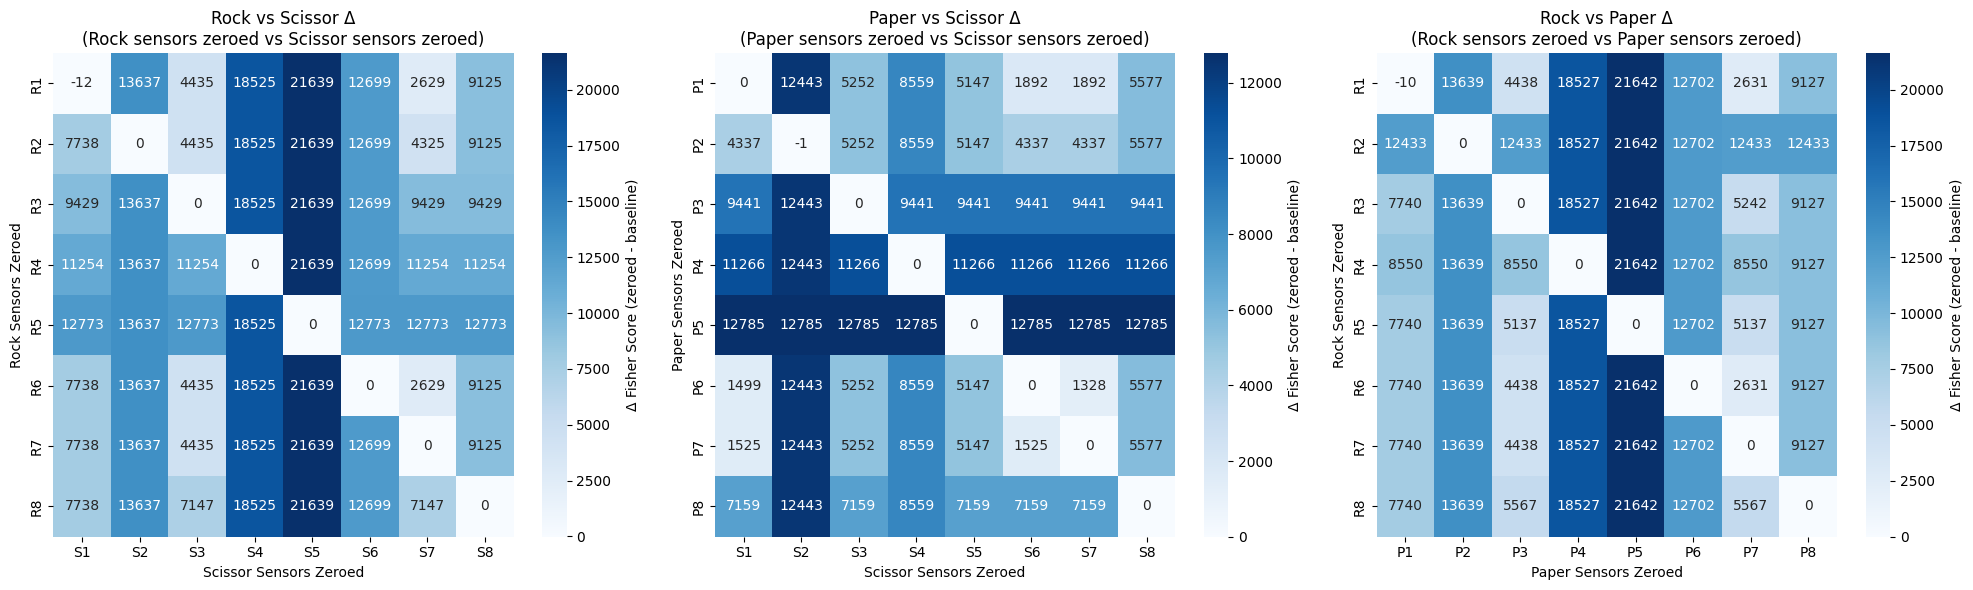

In [ ]:
# Visualize the results with heatmaps
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# load rock_scissor_result.txt
rock_scissor_matrix = np.loadtxt('rock_scissor_result.txt')
paper_scissor_matrix = np.loadtxt('paper_scissor_result.txt')
rock_paper_matrix = np.loadtxt('rock_paper_result.txt')

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Rock vs Scissor heatmap (Δ vs baseline)
sns.heatmap(rock_scissor_matrix, annot=True, fmt='.0f', cmap='Blues', 
            xticklabels=[f'S{j+1}' for j in range(8)], 
            yticklabels=[f'R{i+1}' for i in range(8)],
            ax=axes[0], cbar_kws={'label': 'Δ Fisher Score (zeroed - baseline)'})
axes[0].set_title('Rock vs Scissor Δ\n(Rock sensors zeroed vs Scissor sensors zeroed)')
axes[0].set_xlabel('Scissor Sensors Zeroed')
axes[0].set_ylabel('Rock Sensors Zeroed')

# Paper vs Scissor heatmap (Δ vs baseline)
sns.heatmap(paper_scissor_matrix, annot=True, fmt='.0f', cmap='Blues',
            xticklabels=[f'S{j+1}' for j in range(8)], 
            yticklabels=[f'P{i+1}' for i in range(8)],
            ax=axes[1], cbar_kws={'label': 'Δ Fisher Score (zeroed - baseline)'})
axes[1].set_title('Paper vs Scissor Δ\n(Paper sensors zeroed vs Scissor sensors zeroed)')
axes[1].set_xlabel('Scissor Sensors Zeroed')
axes[1].set_ylabel('Paper Sensors Zeroed')

# Rock vs Paper heatmap (Δ vs baseline)
sns.heatmap(rock_paper_matrix, annot=True, fmt='.0f', cmap='Blues',
            xticklabels=[f'P{j+1}' for j in range(8)], 
            yticklabels=[f'R{i+1}' for i in range(8)],
            ax=axes[2], cbar_kws={'label': 'Δ Fisher Score (zeroed - baseline)'})
axes[2].set_title('Rock vs Paper Δ\n(Rock sensors zeroed vs Paper sensors zeroed)')
axes[2].set_xlabel('Paper Sensors Zeroed')
axes[2].set_ylabel('Rock Sensors Zeroed')

plt.tight_layout()
plt.show()


In [ ]:
# Summary analysis - Find most and least impactful deltas

def analyze_sensor_impact(delta_matrix, class1_name, class2_name):
    """
    Analyze the impact of zeroing out sensors on Fisher score delta (zeroed - baseline)
    """
    print(f"\n{'='*50}")
    print(f"SENSOR IMPACT ANALYSIS (Δ vs baseline): {class1_name} vs {class2_name}")
    print(f"{'='*50}")
    
    # For deltas, most negative = largest drop from baseline (most critical),
    # most positive = largest increase from baseline
    min_delta = np.min(delta_matrix)
    min_indices = np.where(delta_matrix == min_delta)
    
    max_delta = np.max(delta_matrix)
    max_indices = np.where(delta_matrix == max_delta)
    
    print(f"Most negative Δ (largest drop): {min_delta:.4f}")
    print(f"  Occurs when zeroing:")
    for i, j in zip(min_indices[0], min_indices[1]):
        print(f"    {class1_name} sensor {i+1} and {class2_name} sensor {j+1}")
    
    print(f"\nMost positive Δ (largest increase): {max_delta:.4f}")
    print(f"  Occurs when zeroing:")
    for i, j in zip(max_indices[0], max_indices[1]):
        print(f"    {class1_name} sensor {i+1} and {class2_name} sensor {j+1}")
    
    # Calculate average delta per sensor (row-wise for class1, column-wise for class2)
    class1_avg_delta = np.mean(delta_matrix, axis=1)
    class2_avg_delta = np.mean(delta_matrix, axis=0)
    
    print(f"\nAverage Δ for zeroing each {class1_name} sensor:")
    for i, impact in enumerate(class1_avg_delta):
        print(f"  {class1_name} sensor {i+1}: {impact:.4f}")
    
    print(f"\nAverage Δ for zeroing each {class2_name} sensor:")
    for i, impact in enumerate(class2_avg_delta):
        print(f"  {class2_name} sensor {i+1}: {impact:.4f}")
    
    return class1_avg_delta, class2_avg_delta

# Analyze all three comparisons
rock_scissor_impact = analyze_sensor_impact(rock_scissor_matrix, "Rock", "Scissor")
paper_scissor_impact = analyze_sensor_impact(paper_scissor_matrix, "Paper", "Scissor")
rock_paper_impact = analyze_sensor_impact(rock_paper_matrix, "Rock", "Paper")



SENSOR IMPACT ANALYSIS (Δ vs baseline): Rock vs Scissor
Most negative Δ (largest drop): -11.7025
  Occurs when zeroing:
    Rock sensor 1 and Scissor sensor 1

Most positive Δ (largest increase): 21639.4788
  Occurs when zeroing:
    Rock sensor 1 and Scissor sensor 5
    Rock sensor 2 and Scissor sensor 5
    Rock sensor 3 and Scissor sensor 5
    Rock sensor 4 and Scissor sensor 5
    Rock sensor 6 and Scissor sensor 5
    Rock sensor 7 and Scissor sensor 5
    Rock sensor 8 and Scissor sensor 5

Average Δ for zeroing each Rock sensor:
  Rock sensor 1: 10334.9223
  Rock sensor 2: 9810.9960
  Rock sensor 3: 11848.4244
  Rock sensor 4: 11623.9670
  Rock sensor 5: 12003.5930
  Rock sensor 6: 9716.2043
  Rock sensor 7: 10974.9601
  Rock sensor 8: 11066.7170

Average Δ for zeroing each Scissor sensor:
  Scissor sensor 1: 8049.5484
  Scissor sensor 2: 11932.3721
  Scissor sensor 3: 6114.5485
  Scissor sensor 4: 16209.5919
  Scissor sensor 5: 18934.5439
  Scissor sensor 6: 11121.2678
  Sci

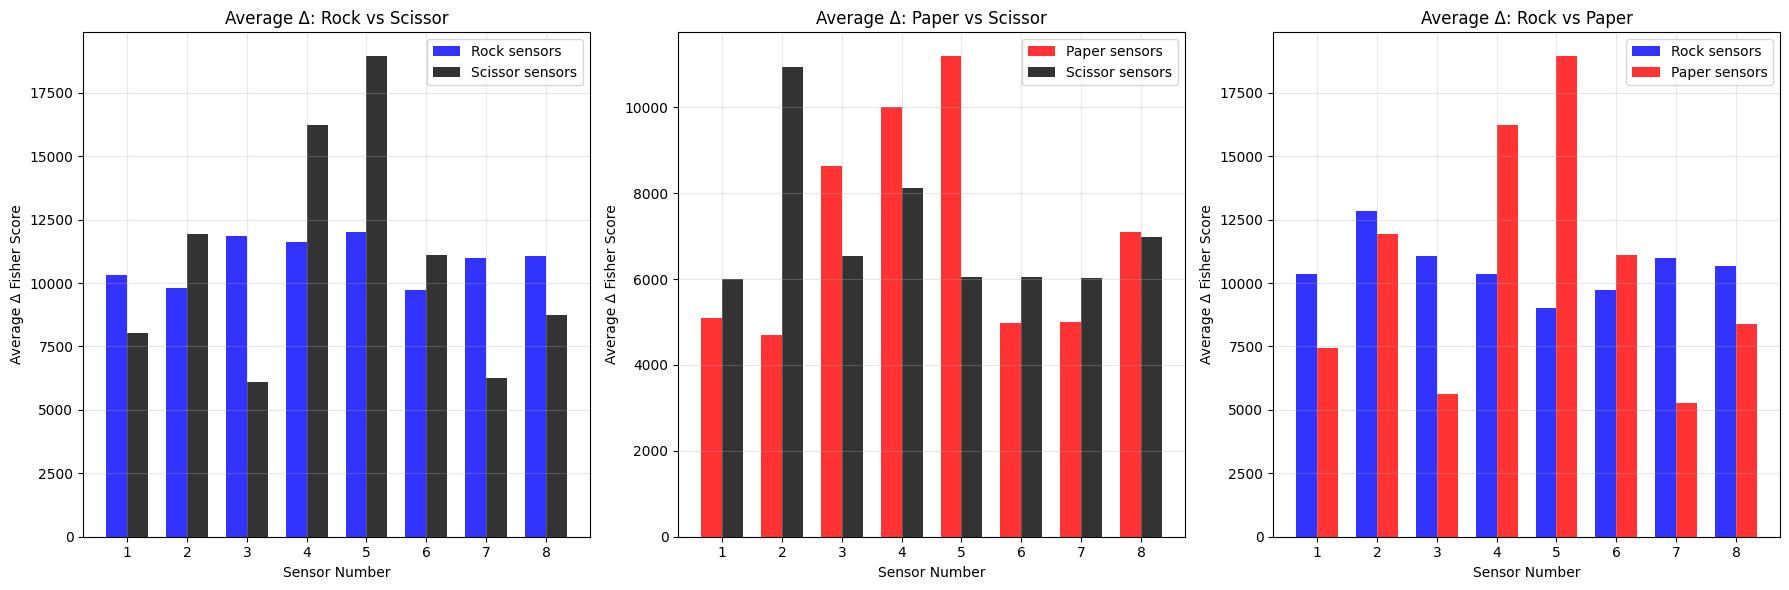


SUMMARY: SENSOR IMPACT (Δ vs baseline)
More negative Δ indicates more important sensors (bigger drop when zeroed)
More positive Δ indicates less important sensors (increase when zeroed)
  Sensor  Rock_vs_Scissor_Δ  Paper_vs_Scissor_Δ  Rock_vs_Paper_Δ  Overall_Avg_Δ
Sensor_6        9716.204336         4975.827157      9717.996191    8136.675895
Sensor_1       10334.922273         5095.316174     10336.955127    8589.064525
Sensor_7       10974.960082         5003.738219     10976.751942    8985.150081
Sensor_2        9810.996034         4693.397468     12825.477638    9109.957046
Sensor_8       11066.716984         7099.879299     10672.924031    9613.173438
Sensor_3       11848.424426         8635.956608     11077.359254   10520.580096
Sensor_4       11623.967000        10004.867063     10344.721234   10657.851765
Sensor_5       12003.592950        11187.129187      9001.241299   10730.654479


In [ ]:

# Visualize average sensor delta (Δ vs baseline) with side-by-side bars, using:
#   Rock = blue, Paper = red, Scissor = green
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

bar_width = 0.35
x = np.arange(1, 9)

# Rock vs Scissor average Δ
rock_avg, scissor_avg = rock_scissor_impact
axes[0].bar(x - bar_width/2, rock_avg, width=bar_width, alpha=0.8, label='Rock sensors', color='blue')
axes[0].bar(x + bar_width/2, scissor_avg, width=bar_width, alpha=0.8, label='Scissor sensors', color='black')
axes[0].set_title('Average Δ: Rock vs Scissor')
axes[0].set_xlabel('Sensor Number')
axes[0].set_ylabel('Average Δ Fisher Score')
axes[0].set_xticks(x)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Paper vs Scissor average Δ
paper_avg, scissor_avg2 = paper_scissor_impact
axes[1].bar(x - bar_width/2, paper_avg, width=bar_width, alpha=0.8, label='Paper sensors', color='red')
axes[1].bar(x + bar_width/2, scissor_avg2, width=bar_width, alpha=0.8, label='Scissor sensors', color='black')
axes[1].set_title('Average Δ: Paper vs Scissor')
axes[1].set_xlabel('Sensor Number')
axes[1].set_ylabel('Average Δ Fisher Score')
axes[1].set_xticks(x)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Rock vs Paper average Δ
rock_avg2, paper_avg2 = rock_paper_impact
axes[2].bar(x - bar_width/2, rock_avg2, width=bar_width, alpha=0.8, label='Rock sensors', color='blue')
axes[2].bar(x + bar_width/2, paper_avg2, width=bar_width, alpha=0.8, label='Paper sensors', color='red')
axes[2].set_title('Average Δ: Rock vs Paper')
axes[2].set_xlabel('Sensor Number')
axes[2].set_ylabel('Average Δ Fisher Score')
axes[2].set_xticks(x)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary table
print("\n" + "="*80)
print("SUMMARY: SENSOR IMPACT (Δ vs baseline)")
print("="*80)
print("More negative Δ indicates more important sensors (bigger drop when zeroed)")
print("More positive Δ indicates less important sensors (increase when zeroed)")
print("="*80)

# Create summary dataframe
import pandas as pd

summary_data = []
for i in range(8):
    summary_data.append({
        'Sensor': f'Sensor_{i+1}',
        'Rock_vs_Scissor_Δ': rock_scissor_impact[0][i],
        'Paper_vs_Scissor_Δ': paper_scissor_impact[0][i], 
        'Rock_vs_Paper_Δ': rock_paper_impact[0][i],
        'Overall_Avg_Δ': np.mean([rock_scissor_impact[0][i], paper_scissor_impact[0][i], rock_paper_impact[0][i]])
    })

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('Overall_Avg_Δ')
print(summary_df.to_string(index=False))


## Note: not for the paper anymore. Was experimenting here:


rock feature matrix: (296, 72)
paper feature matrix: (296, 72)
scissor feature matrix: (296, 72)


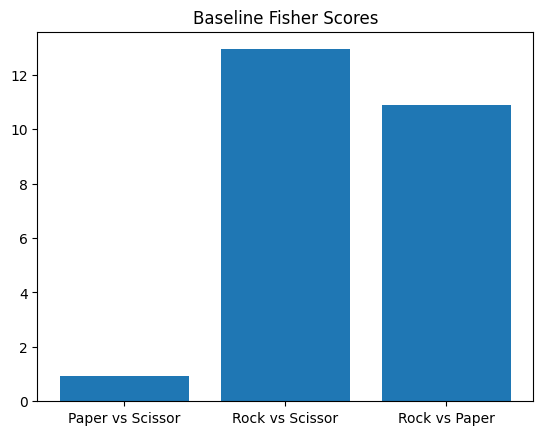

In [ ]:
# ================================
# Full pipeline: EMG features + Fisher + Ablation + Shapley
# ================================
import torch
import numpy as np
import pywt
from scipy.signal import welch
import os
import itertools
from math import factorial
import pandas as pd
import matplotlib.pyplot as plt

# ---------- Feature functions ----------
def rms(signal):
    return np.sqrt(np.mean(signal**2))

def waveform_length(signal):
    return np.sum(np.abs(np.diff(signal)))

def zero_crossings(signal, threshold=0.01):
    return np.sum(((signal[:-1] * signal[1:]) < 0) &
                  (np.abs(signal[:-1] - signal[1:]) > threshold))

def slope_sign_changes(signal, threshold=0.01):
    diff = np.diff(signal)
    return np.sum(((diff[:-1] * diff[1:]) < 0) &
                  (np.abs(diff[:-1] - diff[1:]) > threshold))

def median_freq(signal, fs=1000):
    freqs, psd = welch(signal, fs=fs, nperseg=min(256, len(signal)))
    cumulative = np.cumsum(psd)
    cutoff = cumulative[-1] / 2
    return freqs[np.where(cumulative >= cutoff)[0][0]]

def sample_entropy(signal, m=2, r=0.2):
    N = len(signal)
    r *= np.std(signal)
    def _phi(m):
        x = np.array([signal[i:i+m] for i in range(N - m + 1)])
        C = np.sum(np.sum(np.abs(x[:,None] - x[None,:]), axis=2) <= r, axis=0) - 1
        return np.sum(C) / ((N - m + 1) * (N - m))
    ratio = _phi(m+1) / (_phi(m) + 1e-12)
    return -np.log(np.clip(ratio, 1e-12, None))

def shannon_entropy(signal, bins=30):
    hist, _ = np.histogram(signal, bins=bins, density=True)
    hist = np.clip(hist, 1e-12, None)
    return -np.sum(hist * np.log2(hist))

def wavelet_energy(signal, wavelet='db4', level=3):
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    energies = [np.sum(np.square(c)) for c in coeffs]
    return np.sum(energies)

def higuchi_fd(signal, kmax=10):
    N = len(signal)
    L = []
    x = signal
    for k in range(1, kmax+1):
        Lk = []
        for m in range(k):
            idx = np.arange(m, N, k)
            Lm = np.sum(np.abs(np.diff(x[idx]))) * (N-1)/(((N-m)//k) * k)
            Lk.append(Lm)
        L.append(np.mean(Lk))
    L = np.log(np.clip(L, 1e-12, None))
    ln_k = np.log(np.clip(1.0/np.arange(1, kmax+1), 1e-12, None))
    return -np.polyfit(ln_k, L, 1)[0]

# ---------- Feature extractor ----------
def extract_emg_features(emg_tensor, fs=1000):
    emg_np = emg_tensor.squeeze(1).numpy()  # [samples, channels, timesteps]
    n_samples, n_channels, n_timesteps = emg_np.shape
    features = []
    for s in range(n_samples):
        sample_feats = []
        for ch in range(n_channels):
            sig = emg_np[s, ch, :]
            feats = [
                rms(sig),
                waveform_length(sig),
                zero_crossings(sig),
                slope_sign_changes(sig),
                median_freq(sig, fs),
                sample_entropy(sig),
                shannon_entropy(sig),
                wavelet_energy(sig),
                higuchi_fd(sig),
            ]
            sample_feats.extend(feats)
        features.append(sample_feats)
    return np.array(features)

# ---------- Fisher score ----------
def compute_fisher_scores(data1, data2):
    m1 = np.mean(data1, axis=0)
    m2 = np.mean(data2, axis=0)
    v1 = np.var(data1, axis=0, ddof=0)
    v2 = np.var(data2, axis=0, ddof=0)
    scores = (m1 - m2)**2 / (v1 + v2 + 1e-12)
    return np.max(scores)

# ---------- Shapley computation ----------
def fisher_value(subset, class1_data, class2_data, fs=100):
    if len(subset) == 0:
        return 0.0
    mask = torch.zeros(class1_data.shape[2], dtype=torch.bool)
    mask[list(subset)] = True
    class1_masked = class1_data.clone()
    class2_masked = class2_data.clone()
    class1_masked[:, :, ~mask, :] = 0
    class2_masked[:, :, ~mask, :] = 0
    f1 = extract_emg_features(class1_masked, fs=fs)
    f2 = extract_emg_features(class2_masked, fs=fs)
    return compute_fisher_scores(f1, f2)

def exact_shapley(n, value_func):
    players = list(range(n))
    all_vals = {}
    for r in range(n+1):
        for comb in itertools.combinations(players, r):
            all_vals[comb] = value_func(comb)
    fact = [factorial(i) for i in range(n+1)]
    shap = np.zeros(n)
    for i in players:
        contrib = 0.0
        for r in range(n):
            for S in itertools.combinations([p for p in players if p!=i], r):
                S_union = tuple(sorted(S + (i,)))
                weight = fact[r] * fact[n-r-1] / fact[n]
                marginal = all_vals[S_union] - all_vals[S]
                contrib += weight * marginal
        shap[i] = contrib
    return shap, all_vals

# ---------- Example usage ----------
if __name__ == "__main__":
    dir_loaders = "dataloaders"
    fs = 100  # Hz
    types = ["rock", "paper", "scissor"]

    # Load all three classes
    feature_data = {}
    raw_data = {}
    for _type in types:
        loader = torch.load(os.path.join(dir_loaders, f"{_type}_dataloader_zeros.pt"), weights_only=False)
        all_x = []
        for x, y in loader:
            all_x.append(x[y==1])
        all_x = torch.cat(all_x, dim=0)
        raw_data[_type] = all_x
        feature_data[_type] = extract_emg_features(all_x, fs=fs)
        print(f"{_type} feature matrix:", feature_data[_type].shape)

    # Pairwise Fisher scores
    paper_scissor = compute_fisher_scores(feature_data["paper"], feature_data["scissor"])
    rock_scissor = compute_fisher_scores(feature_data["rock"], feature_data["scissor"])
    rock_paper = compute_fisher_scores(feature_data["rock"], feature_data["paper"])
    plt.bar(["Paper vs Scissor", "Rock vs Scissor", "Rock vs Paper"],
            [paper_scissor, rock_scissor, rock_paper])
    plt.title("Baseline Fisher Scores")
    plt.show()

    # Shapley values for all three class pairs
    class_pairs = [
        ("paper", "scissor"),
        ("rock", "scissor"),
        ("rock", "paper"),
    ]
    pair_names = [
        "Paper vs Scissor",
        "Rock vs Scissor",
        "Rock vs Paper",
    ]

    for (class1, class2), pair_name in zip(class_pairs, pair_names):
        class1_data = raw_data[class1]
        class2_data = raw_data[class2]
        n_sensors = class1_data.shape[2]

        shap_vals, all_vals = exact_shapley(
            n_sensors,
            lambda S: fisher_value(S, class1_data, class2_data, fs=fs)
        )

        sensors = [f"sensor_{i}" for i in range(n_sensors)]
        shap_df = pd.DataFrame({"sensor": sensors, "shapley": shap_vals})
        shap_df = shap_df.sort_values("shapley", ascending=False).reset_index(drop=True)
        print(f"\nShapley importances ({pair_name}):")
        print(shap_df)
